In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\3_comp
scenario=3comp_equal  K_MODEL=5  K_TRUE=3
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt1       [-5.48, +10.95]
  Alt2       [-9.74, +13.24]
  Alt3       [-5.16, +11.82]
  Price      [-14.81, +3.74]


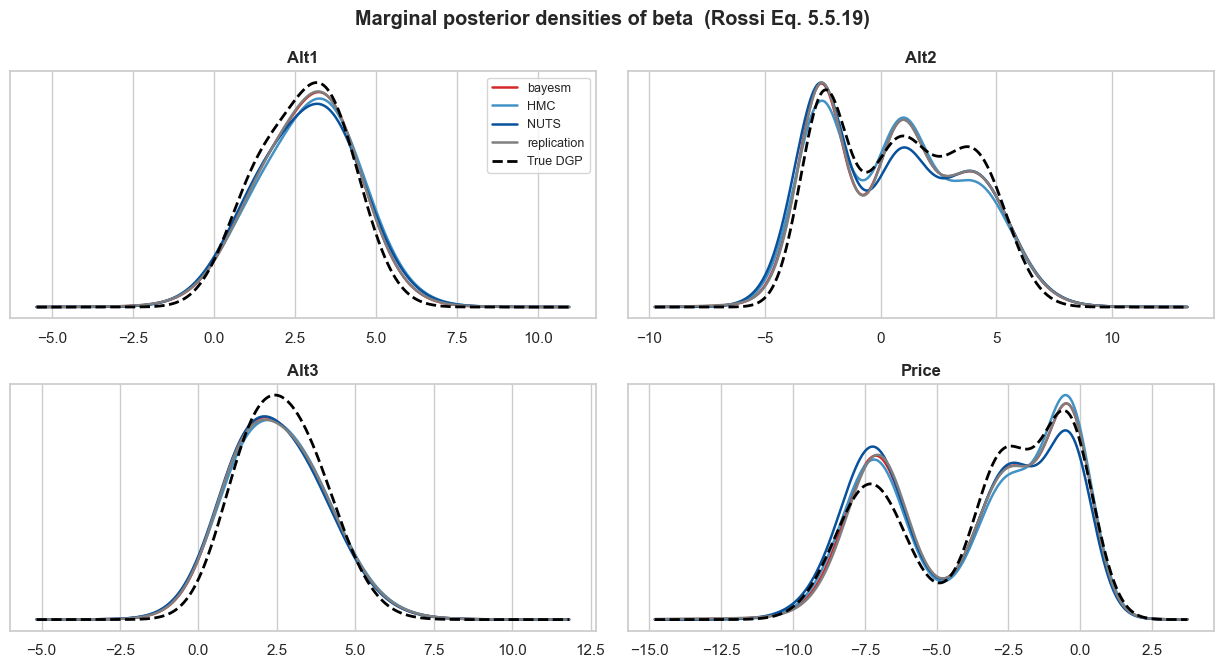

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06967  0.03077  0.00453  0.05039       0.15690
            Alt2     0.07278  0.03145  0.00500  0.06364       0.23525
            Alt3     0.07692  0.03084  0.00569  0.07137       0.19088
            Price    0.05221  0.01426  0.00262  0.05614       0.17431
HMC         Alt1     0.08851  0.04408  0.00745  0.07224       0.22617
            Alt2     0.08120  0.03713  0.00627  0.06793       0.28304
            Alt3     0.08109  0.03535  0.00630  0.07111       0.19114
            Price    0.04797  0.00997  0.00227  0.05602       0.16311
NUTS        Alt1     0.08210  0.03897  0.00638  0.06397       0.17754
            Alt2     0.09032  0.04517  0.00777  0.07689       0.37129
            Alt3     0.08361  0.03707  0.00672  0.07704       0.21805
            Price    0.06046  0.01552  0.00363  0.07665       0.45124
replication Alt1     0.07220  0.03385  0.00484  0.05077       0.16101
            Alt2     0.07383  0.03660  0.00506  0.06251       0.23169
            Alt3     0.07814  0.03192  0.00587  0.07236       0.19099
            Price    0.06099  0.02319  0.00349  0.06122       0.17762

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.824,2.899,2.847,2.826,2.719
Alt2,0.623,0.577,0.505,0.628,0.781
Alt3,2.517,2.533,2.461,2.520,2.635
Price,-3.606,-3.576,-3.894,-3.607,-3.454


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.665,4.176,5.302,2.709,2.072
Alt2,9.795,10.354,11.251,9.844,8.600
Alt3,2.725,3.016,5.438,2.787,1.993
Price,9.697,10.020,10.106,9.772,9.352


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,23,544.847,941.665,1.009,1.003
Alt2,26,217.565,712.442,1.006,1.002
Alt3,22,620.597,1036.211,1.007,1.002
Price,28,149.769,2375.040,1.010,1.004


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,24,38.021,571.037,1.055,1.017
Alt2,26,9.754,259.211,1.142,1.033
Alt3,22,275.004,672.323,1.022,1.007
Price,28,7.160,348.385,1.191,1.045


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,24,25.052,644.890,1.062,1.022
Alt2,26,5.238,656.631,1.301,1.065
Alt3,22,10.010,410.452,1.138,1.057
Price,28,3.342,596.087,1.593,1.119


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,23,267.724,753.206,1.010,1.004
Alt2,26,106.857,620.687,1.014,1.004
Alt3,22,169.892,822.988,1.017,1.007
Price,28,105.870,2336.265,1.020,1.005


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt1  Mean     760.9175  1.0038
      Var      983.5324  1.0046
Alt2  Mean    1245.0198  1.0007
      Var      700.8123  1.0017
Alt3  Mean    1199.1225  1.0007
      Var     1114.3913  1.0006
Price Mean     667.8325  1.0054
      Var      160.2739  1.0175

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean    123.9628  1.0270
      Var       7.7835  1.1937
Alt2  Mean     23.1720  1.0715
      Var       6.9074  1.2060
Alt3  Mean    622.8407  1.0086
      Var      14.1015  1.1107
Price Mean     22.8633  1.0642
      Var     313.9813  1.0095

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean     31.9763  1.0587
      Var      11.1570  1.1273
Alt2  Mean      7.2457  1.1972
      Var     561.2415  1.0176
Alt3  Mean     15.1981  1.0964
      Var      21.4190  1.0672
Price Mean      3.2248  1.6507
      Var     138.5539  1.0289

--- replication ---


ESS    Rhat
param moment                  
Alt1  Mean    662.5515  1.0056
      Var     748.6398  1.0048
Alt2  Mean    553.1227  1.0047
      Var     275.1611  1.0047
Alt3  Mean    624.8667  1.0042
      Var     336.6900  1.0109
Price Mean    191.0407  1.0070
      Var      89.8410  1.0234


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
